In [404]:
!pip install ucimlrepo

In [405]:
from ucimlrepo import fetch_ucirepo

In [406]:
dataset = fetch_ucirepo(id=697)

In [407]:
dataset.data.features

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,0,6,6,2,11.000000,0,11.1,0.6,2.02
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12


In [408]:
type(dataset)

ucimlrepo.dotdict.dotdict

inspect the official descriptions of those 36 columns so we know what each coded number actually means.

In [409]:
#inspect the official descriptions of those 36 columns so we know what each coded number actually means.
dataset.variables

,name,role,type,demographic,description,units,missing_values
0,Marital Status,Feature,Integer,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...,None,no
1,Application mode,Feature,Integer,None,1 - 1st phase - general contingent 2 - Ordinan...,None,no
2,Application order,Feature,Integer,None,Application order (between 0 - first choice; a...,None,no
3,Course,Feature,Integer,None,33 - Biofuel Production Technologies 171 - Ani...,None,no
4,Daytime/evening attendance,Feature,Integer,None,1 – daytime 0 - evening,None,no
5,Previous qualification,Feature,Integer,Education Level,1 - Secondary education 2 - Higher education -...,None,no
6,Previous qualification (grade),Feature,Continuous,None,Grade of previous qualification (between 0 and...,None,no
7,Nacionality,Feature,Integer,Nationality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...,None,no
8,Mother's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no
9,Father's qualification,Feature,Integer,Education Level,1 - Secondary Education - 12th Year of Schooli...,None,no


In [410]:
dataset.data.targets

,Target
0,Dropout
1,Graduate
2,Dropout
3,Graduate
4,Graduate
...,...
4419,Graduate
4420,Dropout
4421,Dropout
4422,Graduate


In [411]:
#Count how many times each target value appears
dataset.data.targets.value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


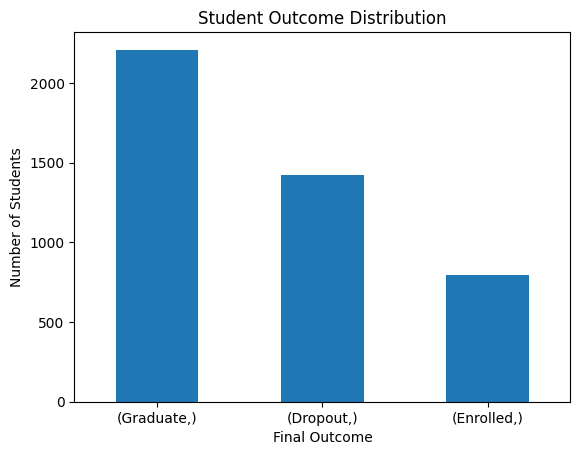

In [412]:
!pip install matplotlib
import matplotlib.pyplot as plt

target_counts = dataset.data.targets.value_counts()

target_counts.plot(kind="bar")

plt.title("Student Outcome Distribution")
plt.xlabel("Final Outcome")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

### Target Distribution

The target variable represents the student's final academic outcome.
There are 3 possible target classes:

- Graduate: 2,209 students
- Dropout: 1,421 students
- Enrolled: 794 students

We check the distribution of these classes before training because the
number of examples for each class is not equal. Graduate is the most
common class, while Enrolled is the least common.

This matters because a machine learning model learns from the examples
available in the training data. If one class is much more common than
the others, the model may become better at predicting the common class
and worse at predicting the less common class.

For example, a model that always predicted "Graduate" would already
be correct for 2,209 out of 4,424 students (about 50%), even though it
would completely fail to identify Dropout and Enrolled students.

Our dataset is not extremely imbalanced, but the classes are clearly
different in size. Therefore, when evaluating our models later, we
should not rely only on overall accuracy. We should also check
precision, recall, F1-score, and the confusion matrix for each class
to make sure the model performs reasonably for Graduate, Dropout,
and Enrolled students.

In [413]:
#check dupplicates
dataset.data.features.duplicated().sum()

np.int64(0)

In [414]:
#check missing values
dataset.data.features.isnull().sum()

,0
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [415]:
dataset.data.features.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


invalid/impossible value check

In [416]:
#invalid/impossible value check
#First check: values that are outside the ranges defined by the UCI metadata.
grade_columns = [
    "Previous qualification (grade)",
    "Admission grade"
]

dataset.data.features[grade_columns].describe()

,Previous qualification (grade),Admission grade
count,4424.000000,4424.000000
mean,132.613314,126.978119
std,13.188332,14.482001
min,95.000000,95.000000
25%,125.000000,117.900000
50%,133.100000,126.100000
75%,140.000000,134.800000
max,190.000000,190.000000


In [417]:
#What actual values occur in each binary column
binary_columns = [
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

for column in binary_columns:
    print(column, dataset.data.features[column].unique())

Displaced [1 0]
Educational special needs [0 1]
Debtor [0 1]
Tuition fees up to date [1 0]
Gender [1 0]
Scholarship holder [0 1]
International [0 1]


In [418]:
#categorical-coded features where describe() looked a little weird
dataset.data.features["Marital Status"].value_counts().sort_index()

,count
Marital Status,
1,3919
2,379
3,4
4,91
5,25
6,6


In [419]:
dataset.data.features["Course"].value_counts().sort_index()

,count
Course,
33,12
171,215
8014,215
9003,210
9070,226
9085,337
9119,170
9130,141
9147,380


In [420]:
dataset.data.features["Application mode"].value_counts().sort_index()

,count
Application mode,
1,1708
2,3
5,16
7,139
10,10
15,30
16,38
17,872
18,124


In [421]:
dataset.data.features["Previous qualification"].value_counts().sort_index()

,count
Previous qualification,
1,3717
2,23
3,126
4,8
5,1
6,16
9,11
10,4
12,45


In [422]:
#logical contradictions between columns
dataset.data.features[
    "Curricular units 1st sem (approved)"
].gt(
    dataset.data.features["Curricular units 1st sem (enrolled)"]
).sum()

np.int64(0)

In [423]:
dataset.data.features[
    "Curricular units 2nd sem (approved)"
].gt(
    dataset.data.features["Curricular units 2nd sem (enrolled)"]
).sum()

np.int64(0)

In [424]:
(dataset.data.features[
    "Curricular units 1st sem (evaluations)"
] > dataset.data.features[
    "Curricular units 1st sem (enrolled)"
]).sum()

np.int64(2792)

In [425]:
dataset.data.features[
    [
        "Course",
        "Curricular units 1st sem (enrolled)",
        "Curricular units 1st sem (evaluations)",
        "Curricular units 1st sem (approved)"
    ]
].head(10)

,Course,Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved)
0,171,0,0,0
1,9254,6,6,6
2,9070,6,0,0
3,9773,6,8,6
4,8014,6,9,5
5,9991,5,10,5
6,9500,7,9,7
7,9254,5,5,0
8,9238,6,8,6
9,9238,6,9,5


In [426]:
dataset.data.features[
    "Curricular units 1st sem (without evaluations)"
].gt(
    dataset.data.features[
        "Curricular units 1st sem (enrolled)"
    ]
).sum()

np.int64(0)

In [427]:
grade_columns = [
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]

dataset.data.features[grade_columns].describe()

,Curricular units 1st sem (grade),Curricular units 2nd sem (grade)
count,4424.000000,4424.000000
mean,10.640822,10.230206
std,4.843663,5.210808
min,0.000000,0.000000
25%,11.000000,10.750000
50%,12.285714,12.200000
75%,13.400000,13.333333
max,18.875000,18.571429


In [428]:
dataset.data.features["Age at enrollment"].describe()

,Age at enrollment
count,4424.000000
mean,23.265145
std,7.587816
min,17.000000
25%,19.000000
50%,20.000000
75%,25.000000
max,70.000000


In [429]:
#Across all 10 curricular-unit count columns, how many negative values exist?
unit_columns = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (without evaluations)"
]

(dataset.data.features[unit_columns] < 0).sum().sum()

np.int64(0)

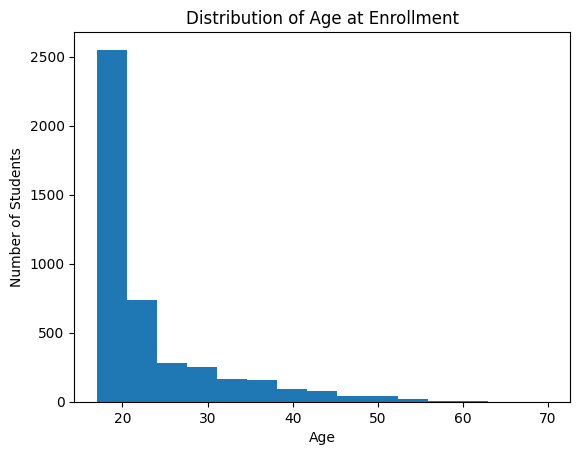

In [430]:
#how the students are distributed across those ages.
#

dataset.data.features["Age at enrollment"].plot(kind="hist", bins=15)

plt.title("Distribution of Age at Enrollment")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.show()

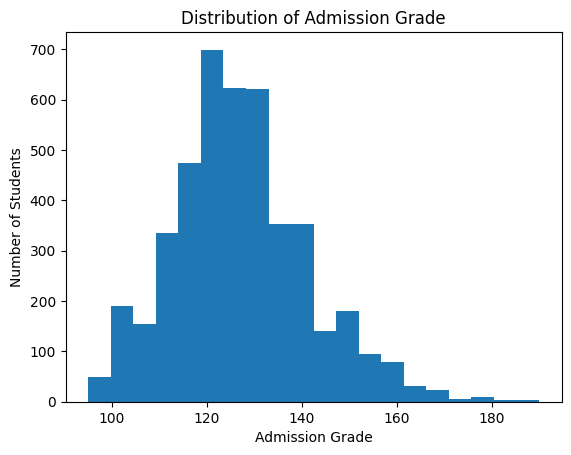

In [431]:
dataset.data.features["Admission grade"].plot(kind="hist", bins=20)

plt.title("Distribution of Admission Grade")
plt.xlabel("Admission Grade")
plt.ylabel("Number of Students")
plt.show()

In [432]:
# Check statistical outliers using the IQR method(Interquartile Range)

numeric_columns = [
    "Age at enrollment",
    "Admission grade",
    "Previous qualification (grade)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]

for column in numeric_columns:
    Q1 = dataset.data.features[column].quantile(0.25)
    Q3 = dataset.data.features[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataset.data.features[
        (dataset.data.features[column] < lower_bound) |
        (dataset.data.features[column] > upper_bound)
    ]

    print(column)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of statistical outliers:", len(outliers))
    print()

Age at enrollment
Lower bound: 10.0
Upper bound: 34.0
Number of statistical outliers: 441

Admission grade
Lower bound: 92.55
Upper bound: 160.15000000000003
Number of statistical outliers: 86

Previous qualification (grade)
Lower bound: 102.5
Upper bound: 162.5
Number of statistical outliers: 179

Curricular units 1st sem (grade)
Lower bound: 7.3999999999999995
Upper bound: 17.0
Number of statistical outliers: 726

Curricular units 2nd sem (grade)
Lower bound: 6.8750000049999995
Upper bound: 17.208333325
Number of statistical outliers: 877



In [433]:
#feature–target relationship analysis.

#Do the students' characteristics actually differ depending on their final outcome?
dataset.data.features.groupby(
    dataset.data.targets["Target"]
)["Curricular units 1st sem (grade)"].mean()

#Firstsemester academic performance appears to be strongly associated with eventual academic outcome.

,Curricular units 1st sem (grade)
Target,
Dropout,7.256656
Enrolled,11.125257
Graduate,12.643655


In [434]:
#For each final outcome, what was the average number of first-semester units they approved?
dataset.data.features.groupby(
    dataset.data.targets["Target"]
)["Curricular units 1st sem (approved)"].mean()

,Curricular units 1st sem (approved)
Target,
Dropout,2.551724
Enrolled,4.318640
Graduate,6.232232


In [435]:
#2nd-semester approved unit
dataset.data.features.groupby(
    dataset.data.targets["Target"]
)["Curricular units 2nd sem (approved)"].mean()

,Curricular units 2nd sem (approved)
Target,
Dropout,1.940183
Enrolled,4.057935
Graduate,6.177003


In [436]:
#end -sem grade
dataset.data.features.groupby(
    dataset.data.targets["Target"]
)["Curricular units 2nd sem (grade)"].mean()

,Curricular units 2nd sem (grade)
Target,
Dropout,5.899339
Enrolled,11.117364
Graduate,12.697276


In [437]:
#admission grade
dataset.data.features.groupby(
    dataset.data.targets["Target"]
)["Admission grade"].mean()

#Graduate students had the highest average admission grade (128.79), but the difference between the groups is relatively small:

,Admission grade
Target,
Dropout,124.961365
Enrolled,125.534257
Graduate,128.794432


In [438]:
#Do students' academic results before entering the program differ depending on what they eventually became: Dropout, Enrolled, or Graduate?
dataset.data.features.groupby(
    dataset.data.targets["Target"]
)["Previous qualification (grade)"].mean()

#Pre-admission grades have a weaker separation between outcomes, while actual semester performance shows a much clearer separation.

,Previous qualification (grade)
Target,
Dropout,131.114075
Enrolled,131.208438
Graduate,134.082707


In [439]:
#Within each final outcome group, what percentage of students had their tuition fees up to date vs not up to date?
dataset.data.features.groupby(
    dataset.data.targets["Target"]
)["Tuition fees up to date"].value_counts(normalize=True)

# So there's a strong association:

# Among Dropout students, about one-third were not up to date with tuition fees.
# Among Enrolled students, only about 5.3% were not up to date.
# Among Graduate students, only about 1.3% were not up to date.

# That is much stronger separation than we saw with the admission-grade variables.

Target    Tuition fees up to date
Dropout   1                          0.678395
          0                          0.321605
Enrolled  1                          0.947103
          0                          0.052897
Graduate  1                          0.986872
          0                          0.013128
Name: proportion, dtype: float64

In [440]:
#Does Debtor appear to be related to the student's final outcome?
dataset.data.features.groupby(
    dataset.data.targets["Target"]
)["Debtor"].value_counts(normalize=True)

Target    Debtor
Dropout   0         0.780436
          1         0.219564
Enrolled  0         0.886650
          1         0.113350
Graduate  0         0.954278
          1         0.045722
Name: proportion, dtype: float64

In [441]:
#Data leakage

dataset.variables[["name", "description"]]

,name,description
0,Marital Status,1 – single 2 – married 3 – widower 4 – divorce...
1,Application mode,1 - 1st phase - general contingent 2 - Ordinan...
2,Application order,Application order (between 0 - first choice; a...
3,Course,33 - Biofuel Production Technologies 171 - Ani...
4,Daytime/evening attendance,1 – daytime 0 - evening
5,Previous qualification,1 - Secondary education 2 - Higher education -...
6,Previous qualification (grade),Grade of previous qualification (between 0 and...
7,Nacionality,1 - Portuguese; 2 - German; 6 - Spanish; 11 - ...
8,Mother's qualification,1 - Secondary Education - 12th Year of Schooli...
9,Father's qualification,1 - Secondary Education - 12th Year of Schooli...


In [442]:
#data preprosessing stage

# Before we encode, scale, or build any pipeline, we need to explicitly define:

# X → the 36 input features the model is allowed to see.
# y → the target we want the model to predict.

dataset.data.features

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,0,6,6,2,11.000000,0,11.1,0.6,2.02
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12


In [443]:

dataset.data.targets

,Target
0,Dropout
1,Graduate
2,Dropout
3,Graduate
4,Graduate
...,...
4419,Graduate
4420,Dropout
4421,Dropout
4422,Graduate


In [444]:
X = dataset.data.features
y = dataset.data.targets["Target"]

In [445]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget classes:")
print(y.value_counts())

X shape: (4424, 36)
y shape: (4424,)

Target classes:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [446]:
#Data Type / Feature Role Identification.
#identify column types
#This matters because we cannot just scale all 36 columns cause from EDA we found that columns like Course and Application mode contain numeric codes but represent categories.
for column in X.columns:
    print(column)

Marital Status
Application mode
Application order
Course
Daytime/evening attendance
Previous qualification
Previous qualification (grade)
Nacionality
Mother's qualification
Father's qualification
Mother's occupation
Father's occupation
Admission grade
Displaced
Educational special needs
Debtor
Tuition fees up to date
Gender
Scholarship holder
Age at enrollment
International
Curricular units 1st sem (credited)
Curricular units 1st sem (enrolled)
Curricular units 1st sem (evaluations)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 1st sem (without evaluations)
Curricular units 2nd sem (credited)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (evaluations)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)
Curricular units 2nd sem (without evaluations)
Unemployment rate
Inflation rate
GDP


In [447]:
#Data Type / Feature Role Identification.
#column groups
# Why are we doing this?
# Because preprocessing is not one operation applied to every column.
# We need different treatment
categorical_columns = [
    "Marital Status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

numerical_columns = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

binary_columns = [
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

In [448]:
#count check
print("Categorical:", len(categorical_columns))
print("Numerical:", len(numerical_columns))
print("Binary:", len(binary_columns))
print("Total:", len(categorical_columns) + len(numerical_columns) + len(binary_columns))

Categorical: 11
Numerical: 18
Binary: 7
Total: 36


In [449]:
#check with all x
all_preprocessing_columns = (
    categorical_columns
    + numerical_columns
    + binary_columns
)

print("Missing columns:", set(X.columns) - set(all_preprocessing_columns))
print("Extra columns:", set(all_preprocessing_columns) - set(X.columns))
print("Duplicate columns:", len(all_preprocessing_columns) - len(set(all_preprocessing_columns)))

Missing columns: set()
Extra columns: set()
Duplicate columns: 0


In [450]:
#Train/Test Splitting

##################################################################################
#*********************************MUST READ**************************************#
##################################################################################

# We don't necessarily do every cleaning operation before the split.

# Think of it as two categories:

# ### 1. Cleaning that does NOT learn anything from the data

# These can happen before splitting.

# For example:

# * Checking whether values are negative
# * Checking whether grades are outside `0–20`
# * Checking duplicates
# * Checking whether required columns exist
# * Removing an obviously corrupted row if you have a fixed external rule

# We already did most of these during EDA.

# ### 2. Cleaning/preprocessing that learns from the data

# This is where the train/test split needs to happen first.

# Examples:

# * Filling missing values using the mean
# * Scaling using mean/std
# * Standardization
# * Learning category mappings
# * Feature selection based on statistics
# * Anything where the dataset is used to calculate parameters

# Why?

# Suppose we do:

# ```text
# Entire dataset
#      ↓
# calculate average age = 23.26
#      ↓
# fill missing ages
#      ↓
# split train/test
# ```

# The average `23.26` was calculated using test-set students too.

# That's information from the test set leaking into training.

# Instead:

# ```text
# Entire dataset
#      ↓
# Train/Test Split
#      ↓
#  ┌──────────────┐
#  │   Training   │ → calculate mean, scaler parameters, encodings...
#  └──────────────┘
#         ↓
#    learn rules
#         ↓
#  ┌──────────────┐
#  │     Test     │ → apply those same rules
#  └──────────────┘
# ```

# ### And this is exactly why we're building the Pipeline

# Eventually:

# ```text
# X_train
#    ↓
# Pipeline.fit()
#    ↓
# learn preprocessing parameters
#    ↓
# transform X_train
#    ↓
# train model
# ```

# Then:

# ```text
# X_test
#    ↓
# Pipeline.predict()
#    ↓
# use SAME learned preprocessing
#    ↓
# prediction
# ```

# No learning from the test set.


#####################################################################
# But here's the key distinction:

# ### We don't need every rare value represented in both sets

# Suppose we have:

# ```text
# Age 70 → 1 student
# Age 69 → 2 students
# Age 68 → 3 students
# ...
# Age 20 → hundreds of students
# ```

# If the **one 70-year-old** goes into the test set:

# ```text
# Training: no 70-year-old
# Test:     70-year-old
# ```

# That is **not automatically a problem**.

# The model isn't supposed to memorize:

# > "I have seen an age 70 before."

# It's supposed to learn relationships from the training data and then **generalize to unseen students**.

# In fact, having unusual cases in the test set can be useful because we're asking:

# > "Can my model handle students it hasn't seen before?"

# ---

# ### But what about rare *classes*?

# This is where `stratify=y` matters.

# Your target has:

# ```text
# Graduate    2209
# Dropout     1421
# Enrolled     794
# ```

# We don't want random splitting to accidentally produce something like:

# ```text
# Train:
# Graduate 1760
# Dropout  1130
# Enrolled  640

# Test:
# Graduate 449
# Dropout  291
# Enrolled  154
# ```

# We want the **class proportions preserved approximately**.

# That's what:

# ```python
# stratify=y
# ```

# means.

# It says:

# > "When splitting, maintain the distribution of the target classes."

# It does **not** mean:

# > "Make every age/course/category appear in both sets."

# ### And  70-year-old example is actually useful

# Imagine,

# A future student comes in and happens to be 70.

# We can't say:

# > "Sorry, our training dataset didn't contain a 70-year-old, so we can't predict."

# The whole purpose of the test set is to measure how well the model handles **unseen data**.

# There is one caveat: if a category/value is *so rare* that the model cannot reasonably learn anything about it, that's a limitation of the dataset—not something we solve by forcing that exact value into both train and test.

#gives us roughly **80% training / 20% testing**, while preserving the **Dropout/Enrolled/Graduate distribution**.



In [451]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [452]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3539, 36)
X_test: (885, 36)
y_train: (3539,)
y_test: (885,)


In [453]:
#preprocessing pipeline.
# Categorical features contain codes that represent categories rather than real numerical values.
# For example, a Course value of 9500 is an identifier, so it should not be interpreted
# as mathematically greater than a Course value of 171. OneHotEncoder converts each
# category into separate binary (0/1) columns so machine learning models can use them
# without assuming a numerical order or distance between categories.
from sklearn.preprocessing import OneHotEncoder

In [454]:
# Create the encoder that will learn the categories from the training data
# and convert each category into a separate 0/1 column.
encoder = OneHotEncoder(handle_unknown="ignore")

In [455]:
# Learn the unique categories present in the training data.
# These learned categories will later be used to convert both the training
# and test categorical values into the same set of 0/1 columns.
encoder.fit(X_train[categorical_columns])

OneHotEncoder(handle_unknown='ignore')

In [456]:
# The encoder has simply learned the mapping.

# Next we'll ask it:

# "What categories did you learn, and how many one-hot columns will this eventually create?"
# Display the categories learned from the training data for each categorical feature.
for column, categories in zip(categorical_columns, encoder.categories_):
    print(column, ":", categories)

Marital Status : [1 2 3 4 5 6]
Application mode : [ 1  2  5  7 10 15 16 17 18 26 27 39 42 43 44 51 53 57]
Application order : [0 1 2 3 4 5 6 9]
Course : [  33  171 8014 9003 9070 9085 9119 9130 9147 9238 9254 9500 9556 9670
 9773 9853 9991]
Daytime/evening attendance : [0 1]
Previous qualification : [ 1  2  3  4  5  6  9 10 12 14 15 19 38 39 40 42 43]
Nacionality : [  1   2   6  11  13  14  21  22  24  25  26  32  41  62 100 101 103 105
 108]
Mother's qualification : [ 1  2  3  4  5  6  9 10 11 12 14 18 19 22 26 29 30 34 35 36 37 38 39 40
 41 42 43 44]
Father's qualification : [ 1  2  3  4  5  6  9 10 11 12 14 18 19 20 22 25 26 27 29 30 31 34 35 36
 37 38 39 40 41 42 43 44]
Mother's occupation : [  0   1   2   3   4   5   6   7   8   9  10  90  99 122 123 131 132 134
 141 143 144 151 152 153 171 173 175 191 192 193 194]
Father's occupation : [  0   1   2   3   4   5   6   7   8   9  10  90  99 101 102 103 112 122
 123 131 134 135 141 143 144 151 152 153 154 161 163 171 172 175 181 182


In [457]:
# transform the data

# The encoder currently knows the categories, but X_train is still unchanged.
X_train_encoded = encoder.transform(X_train[categorical_columns])

In [458]:
X_train_encoded.shape

(3539, 219)

In [459]:
#standard scaler
# StandardScaler does not mean "make all data standard" in some vague sense.
#
# It means:
# Take a numerical column and change its scale so that values are measured
# relative to that column's average.
#
# Imagine one feature:
#
# Age
# 18
# 20
# 22
# 40
#
# The model initially sees the actual values 18, 20, 22, and 40.
#
# StandardScaler calculates from the training data:
# - the average age
# - how spread out the ages are
#
# It then converts each age into:
#
# "How far is this value from the average, measured in standard deviations?"
#
# Therefore, roughly:
#
# 18  -> negative number   (below average)
# 20  -> negative/small
# 22  -> around average
# 40  -> positive number   (above average)
#
# The important information is the relative position, not the original unit.
#
#
# Why is this useful?
#
# Consider two numerical features:
#
# Age at enrollment        -> around 17-70
# Admission grade          -> around 95-190
#
# Their numerical ranges are different.
#
# There are also features such as:
#
# Curricular units grade   -> 0-20
# GDP                      -> much different scale
#
# For Logistic Regression, different feature scales can make the optimization
# process less efficient. Standardizing the numerical features puts them onto
# a more comparable scale.
#
#
# This does not mean that:
#
# "Age 40 is bad and should become something else."
#
# Instead:
#
# "Keep the information in Age 40, but express it on a common numerical scale."
#
# The transformation is learned only from X_train.
#
#
# Binary features do not require this transformation:
#
# Debtor
# 0
# 1
# 0
# 1
#
# They are already represented on a small 0/1 scale, so they can be passed
# through unchanged.
#
# Therefore:
#
# Categorical -> change representation
# Numerical   -> change scale
# Binary      -> leave unchanged

#################################################################################################################
#################################################################################################################
#standard deviation

# Standard deviation measures how spread out values are around their average.
#
# Consider:
#
# A: 9, 10, 11
#
# Average:
#
# (9 + 10 + 11) / 3 = 10
#
# These values are close to 10.
#
# Now consider:
#
# B: 1, 10, 19
#
# The average is still 10, but the values are much more spread out.
#
# Therefore:
#
# A -> small standard deviation
# B -> large standard deviation
#
# In simple terms:
#
# Small standard deviation = values are clustered together
# Large standard deviation = values are spread out
# Standard deviation can be calculated step by step using a small example.
#
# Values:
#
# 9, 10, 11
#
#
# Step 1 - Find the average
#
# (9 + 10 + 11) / 3 = 10
#
#
# Step 2 - Find how far each value is from the average
#
# 9  -> 9 - 10  = -1
# 10 -> 10 - 10 =  0
# 11 -> 11 - 10 = +1
#
# The deviations are:
#
# -1, 0, +1
#
#
# Step 3 - Square the deviations
#
# The deviations are squared so that negative and positive values do not
# cancel each other out.
#
# Without squaring:
#
# -1 + 0 + 1 = 0
#
# This would incorrectly suggest that there is no spread.
#
# After squaring:
#
# (-1)^2 = 1
# ( 0)^2 = 0
# (+1)^2 = 1
#
#
# Step 4 - Average the squared deviations
#
# (1 + 0 + 1) / 3 = 0.667
#
# This value is called the variance.
#
#
# Step 5 - Take the square root
#
# sqrt(0.667) ≈ 0.816
#
# This is the standard deviation.
#
#
# The complete process is:
#
# values
#   ↓
# find average
#   ↓
# find each value's distance from average
#   ↓
# square those distances
#   ↓
# average them       <- variance
#   ↓
# square root
#   ↓
# standard deviation
#
# This standard deviation value is the σ (sigma) used in the StandardScaler
# formula.
#
# For a sample rather than an entire population, the variance calculation
# uses n - 1 instead of n. StandardScaler uses the population-style
# calculation (ddof=0).

In [460]:
##################
###experimental###
##################

values = [9, 10, 11]

# Step 1: Find the average.
mean = sum(values) / len(values)

# Step 2: Find how far each value is from the average.
deviations = [value - mean for value in values]

# Step 3: Square each deviation so positive and negative
# differences cannot cancel each other out.
squared_deviations = [deviation ** 2 for deviation in deviations]

# Step 4: Average the squared differences.
# This is the variance.
variance = sum(squared_deviations) / len(values)

# Step 5: Take the square root of the variance.
# This gives us the standard deviation.
standard_deviation = variance ** 0.5

print("Mean:", mean)
print("Deviations:", deviations)
print("Squared deviations:", squared_deviations)
print("Variance:", variance)
print("Standard deviation:", standard_deviation)

Mean: 10.0
Deviations: [-1.0, 0.0, 1.0]
Squared deviations: [1.0, 0.0, 1.0]
Variance: 0.6666666666666666
Standard deviation: 0.816496580927726


In [461]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler.
#
# StandardScaler will calculate the mean and standard deviation of each
# numerical feature from the training data. It will then use those values
# to express each observation relative to the feature's average and spread.
#
# In other words, instead of keeping a value such as "Age = 30" on its
# original scale, the transformed value tells the model how far that age
# is from the average age in terms of standard deviations.
#
# The scaler learns these values from X_train only. This is important because
# the test data must remain unseen during the learning process.
scaler = StandardScaler()

In [462]:
# The scaler is currently empty. It has not learned anything about the
# numerical features yet.
#
# fit() calculates the mean and standard deviation for each numerical
# feature using X_train only.
#
# For example, for "Age at enrollment", it calculates:
# - the average age in X_train
# - the standard deviation of age in X_train
#
# It does the same thing separately for every numerical column.
scaler.fit(X_train[numerical_columns])

StandardScaler()

In [463]:
# Display the mean learned for each numerical feature.
for column, mean in zip(numerical_columns, scaler.mean_):
    print(column, "-> mean:", mean)

Previous qualification (grade) -> mean: 132.684713195818
Admission grade -> mean: 126.87674484317606
Age at enrollment -> mean: 23.24950551003108
Curricular units 1st sem (credited) -> mean: 0.7171517377790336
Curricular units 1st sem (enrolled) -> mean: 6.265329189036451
Curricular units 1st sem (evaluations) -> mean: 8.2913252331167
Curricular units 1st sem (approved) -> mean: 4.701610624470189
Curricular units 1st sem (grade) -> mean: 10.622980735950835
Curricular units 1st sem (without evaluations) -> mean: 0.13987001977959876
Curricular units 2nd sem (credited) -> mean: 0.545351794292173
Curricular units 2nd sem (enrolled) -> mean: 6.226900254309127
Curricular units 2nd sem (evaluations) -> mean: 8.037863803334275
Curricular units 2nd sem (approved) -> mean: 4.433738344165018
Curricular units 2nd sem (grade) -> mean: 10.204514440502965
Curricular units 2nd sem (without evaluations) -> mean: 0.13930488838654986
Unemployment rate -> mean: 11.580135631534331
Inflation rate -> mean: 1

In [464]:
X_train["Age at enrollment"].head()

,Age at enrollment
2283,21
3874,41
2281,21
817,18
404,19


In [465]:
# Display the standard deviation learned for each numerical feature.
for column, std in zip(numerical_columns, scaler.scale_):
    print(column, "-> standard deviation:", std)

Previous qualification (grade) -> standard deviation: 13.200382774467327
Admission grade -> standard deviation: 14.528653141571926
Age at enrollment -> standard deviation: 7.604089533309404
Curricular units 1st sem (credited) -> standard deviation: 2.379261254432911
Curricular units 1st sem (enrolled) -> standard deviation: 2.4940650599310574
Curricular units 1st sem (evaluations) -> standard deviation: 4.187018369552823
Curricular units 1st sem (approved) -> standard deviation: 3.095033384771679
Curricular units 1st sem (grade) -> standard deviation: 4.870533144240436
Curricular units 1st sem (without evaluations) -> standard deviation: 0.6630276271914111
Curricular units 2nd sem (credited) -> standard deviation: 1.9233306091527826
Curricular units 2nd sem (enrolled) -> standard deviation: 2.219312030220052
Curricular units 2nd sem (evaluations) -> standard deviation: 3.967618514922128
Curricular units 2nd sem (approved) -> standard deviation: 3.0276680074994493
Curricular units 2nd s

In [466]:
# Transform the numerical features using the mean and standard deviation
# learned from X_train.
#
# Each original numerical value is converted into a standardized value.
# The resulting values are centered around 0 and measured in standard
# deviations from their respective feature means.
X_train_scaled = scaler.transform(X_train[numerical_columns])

In [467]:
# Display the first five rows of the scaled numerical features.
X_train_scaled[:5]

array([[-0.96093526, -0.56968425, -0.29582838,  3.48126892,  1.89837502,
         1.36342243,  1.71190056,  0.36485108, -0.21095655,  2.83604295,
         1.70012134,  1.25065859,  1.838465  ,  0.30478051, -0.19553048,
         0.87213808, -1.10347259,  0.33959515],
       [ 0.03146021, -0.47332294,  2.33433528, -0.30141782, -0.50733608,
        -0.78607853, -1.51908236, -2.18107144,  1.29727623, -0.28354553,
        -0.55282909, -0.76566429, -1.46440704, -1.94933578,  6.82254618,
         0.4210058 ,  1.79597205, -0.75662914],
       [ 0.55417232,  0.90326715, -0.29582838, -0.30141782, -0.10638423,
         1.12458899, -0.22668919,  0.23139546, -0.21095655, -0.28354553,
        -0.10223901,  1.75473932, -0.14325822,  0.05644566, -0.19553048,
         1.47364778,  1.143597  , -1.79562084],
       [-0.58215836, -0.41825934, -0.69035293, -0.30141782, -0.10638423,
        -0.54724509,  0.41950739,  0.79601537, -0.21095655, -0.28354553,
        -0.10223901, -0.51362393,  0.51731618,  0.502

In [468]:
# Display the first five rows of the binary features.
#
# These features already use a simple 0/1 representation, so their values
# can be passed directly to the model without encoding or scaling.
X_train[binary_columns].head()

,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International
2283,0,0,0,1,1,0,0
3874,1,0,1,0,1,0,0
2281,0,0,0,1,1,0,0
817,1,0,0,1,0,0,0
404,1,0,0,1,0,0,0


In [469]:
# StandardScaler changes numerical values into a common representation based
# on the distribution of the training data.
#
# During fit(), the scaler learns the mean and standard deviation of each
# numerical feature from X_train. These values become the reference
# measurements for that feature.
#
# During transform(), each value is converted to show how far it is from
# that feature's training-data mean, measured in standard deviations.
#
# For example, if the training data has an average age of 23.25 and a
# standard deviation of 7.60, an age of 21 is represented as approximately
# -0.30. This means 21 is about 0.30 standard deviations below the training
# average.
#
# The scaler must be fitted only on the training data. The same learned
# mean and standard deviation are then used to transform the test data and
# any future student data.
#
# Fitting the scaler again on the test or future data would create a new
# mean and standard deviation, giving the data a different scale from the
# one used when training the model.
#
# Therefore:
# fit()       → learn the measurements from training data
# transform() → use those same measurements on training, test, and new data

In [470]:
from sklearn.compose import ColumnTransformer

# Create a preprocessing transformer that applies a different
# transformation to each type of feature.
#
# Categorical features are one-hot encoded because their numeric values
# represent category codes rather than meaningful numerical distances.
#
# Numerical features are standardized using the mean and standard deviation
# learned from the training data.
#
# Binary features are already represented as 0 and 1, so they are passed
# through without changing their values.
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_columns),
        ("numerical", scaler, numerical_columns),
        ("binary", "passthrough", binary_columns)
    ]
)

In [471]:
# Fit the ColumnTransformer using the training data.
#
# The encoder and scaler have already learned their transformations
# from X_train. The ColumnTransformer coordinates those transformations
# across the corresponding feature groups.
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Marital Status', 'Application mode',
                                  'Application order', 'Course',
                                  'Daytime/evening attendance',
                                  'Previous qualification', 'Nacionality',
                                  "Mother's qualification",
                                  "Father's qualification",
                                  "Mother's occupation",
                                  "Father's occupation"]),
                                ('numerical', StandardScaler(),
                                 ['Previous qua...
                                  'Curricular units 2nd sem (enrolled)',
                                  'Curricular units 2nd sem (evaluations)',
                                  'Curricular units 2nd sem (approved)',
                                  'Curricular units 2nd sem (grade)',
                                  'Curricular units 2nd sem (without '
                                  'evaluations)',
                                  'Unemployment rate', 'Inflation rate',
                                  'GDP']),
                                ('binary', 'passthrough',
                                 ['Displaced', 'Educational special needs',
                                  'Debtor', 'Tuition fees up to date', 'Gender',
                                  'Scholarship holder', 'International'])])

In [472]:
X_train_processed = preprocessor.transform(X_train)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

Original X_train shape: (3539, 36)
Processed X_train shape: (3539, 244)


In [473]:
print(X_train_processed[:5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 156 stored elements and shape (5, 244)>
  Coords	Values
  (0, 0)	1.0
  (0, 19)	1.0
  (0, 25)	1.0
  (0, 41)	1.0
  (0, 50)	1.0
  (0, 64)	1.0
  (0, 68)	1.0
  (0, 88)	1.0
  (0, 115)	1.0
  (0, 148)	1.0
  (0, 180)	1.0
  (0, 219)	-0.9609352556316209
  (0, 220)	-0.5696842482592684
  (0, 221)	-0.29582838289544255
  (0, 222)	3.481268921934828
  (0, 223)	1.898375021177045
  (0, 224)	1.3634224316749275
  (0, 225)	1.711900557066422
  (0, 226)	0.3648510771660694
  (0, 227)	-0.21095654848062514
  (0, 228)	2.8360429453730642
  (0, 229)	1.700121341349534
  (0, 230)	1.2506585948228734
  (0, 231)	1.8384649974989025
  (0, 232)	0.30478050795904976
  :	:
  (4, 68)	1.0
  (4, 107)	1.0
  (4, 139)	1.0
  (4, 152)	1.0
  (4, 183)	1.0
  (4, 219)	0.7056830823269739
  (4, 220)	0.3044504616995338
  (4, 221)	-0.5588447494491348
  (4, 222)	-0.3014178188472894
  (4, 223)	0.6955194709361351
  (4, 224)	-0.06957820754624813
  (4, 225)	0.7426056813598356
  (4, 226

In [474]:
#testing manually on test-set transformation
X_test_processed = preprocessor.transform(X_test)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_test shape: (885, 36)
Processed X_test shape: (885, 244)


In [475]:
print(X_test_processed[:5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 157 stored elements and shape (5, 244)>
  Coords	Values
  (0, 0)	1.0
  (0, 20)	1.0
  (0, 25)	1.0
  (0, 35)	1.0
  (0, 50)	1.0
  (0, 64)	1.0
  (0, 68)	1.0
  (0, 89)	1.0
  (0, 117)	1.0
  (0, 149)	1.0
  (0, 188)	1.0
  (0, 219)	2.0692799042930967
  (0, 220)	2.2798572471969814
  (0, 221)	-0.42733656617228866
  (0, 222)	-0.3014178188472894
  (0, 223)	-0.1063842292244715
  (0, 224)	-0.30841164741644406
  (0, 225)	0.4195073894576402
  (0, 226)	0.6933572083464006
  (0, 227)	-0.21095654848062514
  (0, 228)	-0.2835455286246381
  (0, 229)	-0.10223900525003204
  (0, 230)	-0.26158356692582513
  (0, 231)	0.5173161826050264
  (0, 232)	0.8523906813205095
  :	:
  (4, 68)	1.0
  (4, 87)	1.0
  (4, 115)	1.0
  (4, 156)	1.0
  (4, 187)	1.0
  (4, 219)	0.03146020924372374
  (4, 220)	1.935709723591154
  (4, 221)	-0.29582838289544255
  (4, 222)	-0.3014178188472894
  (4, 223)	-0.1063842292244715
  (4, 224)	-0.30841164741644406
  (4, 225)	0.096409097555444

In [476]:
#verification: prove that the test transformation really used the training scaler
# Select one numerical feature from the first test row.
feature = "Age at enrollment"

test_value = X_test.iloc[0][feature]

# Recalculate the standardized value manually using
# the mean and standard deviation learned from X_train.
manual_scaled_value = (
    test_value - scaler.mean_[numerical_columns.index(feature)]
) / scaler.scale_[numerical_columns.index(feature)]

# Get the same value produced by the ColumnTransformer.
processed_scaled_value = X_test_processed[0, 221]

print("Original test value:", test_value)
print("Manual scaled value:", manual_scaled_value)
print("ColumnTransformer value:", processed_scaled_value)

Original test value: 20.0
Manual scaled value: -0.42733656617228866
ColumnTransformer value: -0.42733656617228866


In [477]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create the preprocessing pipeline for each feature type.
#
# The encoder and scaler are created here without being fitted.
# ColumnTransformer will fit them using X_train when fit() is called.
preprocessor_clean = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("numerical", StandardScaler(), numerical_columns),
        ("binary", "passthrough", binary_columns)
    ]
)

In [478]:
# Fit the preprocessing transformer using only the training data.
#
# The encoder learns the categorical structure and the scaler learns
# the numerical statistics from X_train.
preprocessor_clean.fit(X_train)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Marital Status', 'Application mode',
                                  'Application order', 'Course',
                                  'Daytime/evening attendance',
                                  'Previous qualification', 'Nacionality',
                                  "Mother's qualification",
                                  "Father's qualification",
                                  "Mother's occupation",
                                  "Father's occupation"]),
                                ('numerical', StandardScaler(),
                                 ['Previous qua...
                                  'Curricular units 2nd sem (enrolled)',
                                  'Curricular units 2nd sem (evaluations)',
                                  'Curricular units 2nd sem (approved)',
                                  'Curricular units 2nd sem (grade)',
                                  'Curricular units 2nd sem (without '
                                  'evaluations)',
                                  'Unemployment rate', 'Inflation rate',
                                  'GDP']),
                                ('binary', 'passthrough',
                                 ['Displaced', 'Educational special needs',
                                  'Debtor', 'Tuition fees up to date', 'Gender',
                                  'Scholarship holder', 'International'])])

In [479]:
X_train_clean = preprocessor_clean.transform(X_train)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_clean.shape)

Original X_train shape: (3539, 36)
Processed X_train shape: (3539, 244)


In [480]:
X_test_clean = preprocessor_clean.transform(X_test)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_clean.shape)

Original X_test shape: (885, 36)
Processed X_test shape: (885, 244)


In [481]:
#######################
##feature engineering##
#######################


# Before creating the sem one approval-rate feature , we first need to check
# whether any students have zero enrolled units in the first semester.
#
# The approval rate will be calculated as:
# approved units / enrolled units
#
# Therefore, the enrolled-unit value is the denominator. If it is zero,
# the calculation would become 0 / 0, which is undefined.
#
# A student having zero approved units by itself is not a problem.
# For example, if a student enrolled in 5 units but approved 0,
# the approval rate is simply 0 / 5 = 0.
#
# The problem only occurs when the number of enrolled units is zero.
# So we check the denominator before creating the new feature.
#
# In the training data, 148 students have zero enrolled units in the
# first semester. We then inspect their other first-semester values
# to understand what these records represent rather than immediately
# treating them as missing or invalid data.


(X_train["Curricular units 1st sem (enrolled)"] == 0).sum()

np.int64(148)

In [482]:
# The 148 students with zero enrolled units are checked here to see
# whether their other first-semester values are also consistent with
# having no recorded activity.
#
# If approved units, evaluations, grades, and units without evaluations
# were non-zero while enrolled units were zero, that could indicate an
# inconsistency in the data.
#
# Instead, all of these values are zero for these students. This means
# these records consistently represent students with no recorded
# first-semester activity, rather than an obvious data error.
X_train.loc[
    X_train["Curricular units 1st sem (enrolled)"] == 0,
    [
        "Curricular units 1st sem (enrolled)",
        "Curricular units 1st sem (approved)",
        "Curricular units 1st sem (evaluations)",
        "Curricular units 1st sem (grade)",
        "Curricular units 1st sem (without evaluations)"
    ]
].describe()

,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),Curricular units 1st sem (evaluations),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations)
count,148.0,148.0,148.0,148.0,148.0
mean,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0


In [483]:
# Create the first-semester approval rate.
#
# For students who have enrolled units, the feature represents the
# proportion of enrolled units that were approved.
#
# For students with zero enrolled units, an approval rate cannot be
# mathematically calculated because the denominator is zero. Since
# these students also have zero approved units, zero evaluations,
# zero grades, and zero units without evaluations, we treat this as
# a no-activity case and assign the engineered feature a value of 0.
#
# This does not mean that their mathematical approval percentage is
# literally 0%. It means that there was no enrolled-unit activity
# from which an approval rate could be measured.
import numpy as np
X_train["Sem1_approval_rate"] = np.where(
    X_train["Curricular units 1st sem (enrolled)"] > 0,
    X_train["Curricular units 1st sem (approved)"] /
    X_train["Curricular units 1st sem (enrolled)"],
    0
)

X_test["Sem1_approval_rate"] = np.where(
    X_test["Curricular units 1st sem (enrolled)"] > 0,
    X_test["Curricular units 1st sem (approved)"] /
    X_test["Curricular units 1st sem (enrolled)"],
    0
)

In [484]:
#quick sanity check
X_train["Sem1_approval_rate"].describe()

,Sem1_approval_rate
count,3539.000000
mean,0.696868
std,0.366511
min,0.000000
25%,0.500000
50%,0.833333
75%,1.000000
max,1.000000


In [485]:
X_test["Sem1_approval_rate"].describe()

,Sem1_approval_rate
count,885.000000
mean,0.701952
std,0.360322
min,0.000000
25%,0.600000
50%,0.833333
75%,1.000000
max,1.000000


In [486]:
#Semester 2 approval rate feature
(X_train["Curricular units 2nd sem (enrolled)"] == 0).sum()

np.int64(148)

In [487]:
zero_enrolled_sem2 = X_train[
    X_train["Curricular units 2nd sem (enrolled)"] == 0
]

zero_enrolled_sem2[
    [
        "Curricular units 2nd sem (enrolled)",
        "Curricular units 2nd sem (approved)",
        "Curricular units 2nd sem (evaluations)",
        "Curricular units 2nd sem (grade)",
        "Curricular units 2nd sem (without evaluations)"
    ]
].describe()

,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (approved),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations)
count,148.0,148.0,148.0,148.0,148.0
mean,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0


In [488]:
X_train["Sem2_approval_rate"] = np.where(
    X_train["Curricular units 2nd sem (enrolled)"] > 0,
    X_train["Curricular units 2nd sem (approved)"] /
    X_train["Curricular units 2nd sem (enrolled)"],
    0
)

X_test["Sem2_approval_rate"] = np.where(
    X_test["Curricular units 2nd sem (enrolled)"] > 0,
    X_test["Curricular units 2nd sem (approved)"] /
    X_test["Curricular units 2nd sem (enrolled)"],
    0
)

In [489]:
X_train["Sem2_approval_rate"].describe()

,Sem2_approval_rate
count,3539.000000
mean,0.659722
std,0.384345
min,0.000000
25%,0.369318
50%,0.833333
75%,1.000000
max,1.000000


In [490]:
#The fact that both are exactly 148 is suspicious enough that we should verify whether they are the same 148 students
zero_sem1 = X_train["Curricular units 1st sem (enrolled)"] == 0
zero_sem2 = X_train["Curricular units 2nd sem (enrolled)"] == 0

print("Semester 1 zero-enrolled:", zero_sem1.sum())
print("Semester 2 zero-enrolled:", zero_sem2.sum())
print("Both semesters zero-enrolled:", (zero_sem1 & zero_sem2).sum())
print("Only semester 1 zero-enrolled:", (zero_sem1 & ~zero_sem2).sum())
print("Only semester 2 zero-enrolled:", (~zero_sem1 & zero_sem2).sum())

Semester 1 zero-enrolled: 148
Semester 2 zero-enrolled: 148
Both semesters zero-enrolled: 148
Only semester 1 zero-enrolled: 0
Only semester 2 zero-enrolled: 0


In [491]:
# Every student with zero enrolled curricular units in semester 1 also has zero enrolled curricular
# units in semester 2, and there are no students who have zero in only one semester.
#see what those 148 students actually are in terms of the target.
X_train.loc[
    zero_sem1 & zero_sem2
].shape

(148, 38)

In [492]:
y_train.loc[
    zero_sem1 & zero_sem2
].value_counts()

,count
Target,
Graduate,64
Dropout,63
Enrolled,21


In [493]:
#0 indicates no measurable semester activity for the approval-rate calculation, not that the student literally had a 0% success rate.


In [494]:
#Feature 3 = Grade_change
X_train["Grade_change"] = (
    X_train["Curricular units 2nd sem (grade)"]
    - X_train["Curricular units 1st sem (grade)"]
)

X_test["Grade_change"] = (
    X_test["Curricular units 2nd sem (grade)"]
    - X_test["Curricular units 1st sem (grade)"]
)

In [495]:
X_train["Grade_change"].describe()

,Grade_change
count,3539.000000
mean,-0.418466
std,2.887588
min,-16.142857
25%,-0.600000
50%,0.000000
75%,0.444444
max,16.000000


In [496]:
#Feature 4  Financial_stress
# The idea is to capture a situation that neither Debtor nor Tuition fees up to date captures alone:

# Is the student both a debtor AND behind on tuition fees?

X_train["Financial_stress"] = (
    (X_train["Debtor"] == 1) &
    (X_train["Tuition fees up to date"] == 0)
).astype(int)

X_test["Financial_stress"] = (
    (X_test["Debtor"] == 1) &
    (X_test["Tuition fees up to date"] == 0)
).astype(int)

In [497]:
X_train["Financial_stress"].value_counts()

,count
Financial_stress,
0,3343
1,196


In [498]:
X_train["Financial_stress"].value_counts(normalize=True)

,proportion
Financial_stress,
0,0.944617
1,0.055383


In [499]:
#Of those 196 financially stressed students, what percentage are Dropout, Enrolled, and Graduate?
import pandas as pd
pd.crosstab(
    X_train["Financial_stress"],
    y_train,
    normalize="index"
)

Target,Dropout,Enrolled,Graduate
Financial_stress,,,
0,0.288364,0.184864,0.526772
1,0.882653,0.086735,0.030612


In [500]:
#Feature 5 — approval-rate change
X_train["Approval_rate_change"] = (
    X_train["Sem2_approval_rate"]
    - X_train["Sem1_approval_rate"]
)

X_test["Approval_rate_change"] = (
    X_test["Sem2_approval_rate"]
    - X_test["Sem1_approval_rate"]
)

In [501]:
X_train["Approval_rate_change"].describe()

,Approval_rate_change
count,3539.000000
mean,-0.037146
std,0.189041
min,-1.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.800000


In [502]:
X_train["Approval_rate_change"].value_counts().sort_index()

,count
Approval_rate_change,
-1.000000,8
-0.875000,1
-0.857143,3
-0.833333,8
-0.800000,4
...,...
0.600000,7
0.600000,1
0.666667,1


In [503]:
X_train["Approval_rate_change_group"] = pd.cut(
    X_train["Approval_rate_change"],
    bins=[-1.01, -0.25, -0.01, 0.01, 0.25, 1.01],
    labels=[
        "Large decrease",
        "Small decrease",
        "No change",
        "Small increase",
        "Large increase"
    ]
)

In [504]:
pd.crosstab(
    X_train["Approval_rate_change_group"],
    y_train,
    normalize="index"
)

Target,Dropout,Enrolled,Graduate
Approval_rate_change_group,,,
Large decrease,0.567416,0.272472,0.160112
Small decrease,0.407407,0.263158,0.329435
No change,0.286924,0.109595,0.603481
Small increase,0.194774,0.287411,0.517815
Large increase,0.276423,0.398374,0.325203


In [505]:
# What this tells us

# There is a clear relationship with the final outcome:

# When approval rate drops substantially, Dropout becomes the dominant outcome: 56.7%.
# When approval rate has no change, Graduate is dominant: 60.3%.
# A small increase is also associated with a high Graduate proportion: 51.8%.
# Large increases are more associated with Enrolled (39.8%), although they are not as strongly separated as the large-decrease group.

In [ ]:
###
##
#preprossesing pipeline
##
###


In [510]:
print("Categorical columns:")
for i, col in enumerate(categorical_columns, 1):
    print(i, col)

print("\nNumerical columns:")
for i, col in enumerate(numerical_columns, 1):
    print(i, col)

print("\nBinary columns:")
for i, col in enumerate(binary_columns, 1):
    print(i, col)

print("\nCounts:")
print("Categorical:", len(categorical_columns))
print("Numerical:", len(numerical_columns))
print("Binary:", len(binary_columns))
print("Total:", len(categorical_columns) + len(numerical_columns) + len(binary_columns))

Categorical columns:
1 Marital Status
2 Application mode
3 Application order
4 Course
5 Daytime/evening attendance
6 Previous qualification
7 Nacionality
8 Mother's qualification
9 Father's qualification
10 Mother's occupation
11 Father's occupation

Numerical columns:
1 Previous qualification (grade)
2 Admission grade
3 Age at enrollment
4 Curricular units 1st sem (credited)
5 Curricular units 1st sem (enrolled)
6 Curricular units 1st sem (evaluations)
7 Curricular units 1st sem (approved)
8 Curricular units 1st sem (grade)
9 Curricular units 1st sem (without evaluations)
10 Curricular units 2nd sem (credited)
11 Curricular units 2nd sem (enrolled)
12 Curricular units 2nd sem (evaluations)
13 Curricular units 2nd sem (approved)
14 Curricular units 2nd sem (grade)
15 Curricular units 2nd sem (without evaluations)
16 Unemployment rate
17 Inflation rate
18 GDP

Binary columns:
1 Displaced
2 Educational special needs
3 Debtor
4 Tuition fees up to date
5 Gender
6 Scholarship holder
7 Inter

In [511]:
#creating baseline and engineered copy of data set seperately
engineered_features = [
    "Sem1_approval_rate",
    "Sem2_approval_rate",
    "Grade_change",
    "Financial_stress",
    "Approval_rate_change"
]

# Baseline: original 36 features only
X_train_base = X_train.drop(columns=engineered_features).copy()
X_test_base = X_test.drop(columns=engineered_features).copy()

# Engineered: original 36 + 5 engineered features
X_train_engineered = X_train.copy()
X_test_engineered = X_test.copy()